# Notebook 04 — Surface Relaxation
## Hastelloy N | Hydrogen Interaction Study


---
## 1. Theory & Background
---

### 1.1 Why Surface Relaxation Is Required

In Notebook 03 we built the slab by cutting the bulk crystal along the (12345) plane and placing atoms at ideal bulk lattice positions. These ideal positions are **not** the equilibrium positions for surface atoms. Here is why:

**Broken bonds at the surface:**  
Every atom in the bulk has 12 nearest neighbours (FCC coordination). When we cut the crystal to create a surface, the top layer atoms lose approximately half their neighbours — they have only 6 neighbours below and none above (only vacuum) [1,2]. This broken-bond configuration means:
- The forces on surface atoms are asymmetric — the atoms are pulled inward toward the bulk
- The electron density at the surface redistributes compared to the bulk
- The ideal bulk positions are on a slope of the potential energy surface, not at a minimum [3,4]

If we start adsorption calculations from the unrelaxed slab, every energy we compute will contain an artificial contribution from the surface strain. The adsorption energies, dissociation barriers, and surface coverage will all be wrong [3,5].

**Surface relaxation vs surface reconstruction:**  
Two types of surface structural change can occur [1,2]:
- **Relaxation:** Atoms move perpendicular to the surface (in z) while preserving the lateral surface periodicity. The surface unit cell stays the same. This is what happens on most FCC (12345) metal surfaces.
- **Reconstruction:** Atoms rearrange laterally, changing the surface periodicity (e.g., Au(12345) 22×√3 herringbone). This does NOT occur on Ni-based (12345) surfaces under normal conditions [6,7].

We expect only **relaxation** for Hastelloy N (12345) — no reconstruction.

**Key references:** [1–5]

### 1.2 Surface Contraction and Rumpling

**Surface contraction:**  
The dominant relaxation mode for FCC (12345) surfaces is an inward contraction of the top layer — the top layer moves toward layer 2 (Δd₁₂ < 0). This is driven by the Smoluchowski smoothing effect: the electron density at the surface smooths out, reducing the repulsion that normally maintains the bulk interlayer spacing [1,2,8].

For pure Ni(12345), the first interlayer contraction is typically [8,9]:
$$\frac{\Delta d_{12}}{d_{12345}} \approx -1\% \text{ to } -3\%$$

For Hastelloy N, the contraction magnitude depends on the local composition at the surface — Mo and Cr atoms may relax differently from Ni due to their different atomic radii and electronic structure [6,10].

**Rumpling:**  
In an alloy surface, different element types in the same layer relax by different amounts in z — some move up, some move down. This is called **rumpling** [6,10]. In a random alloy like Hastelloy N, rumpling breaks the perfect flatness of each layer. We quantify this by measuring:
- Mean z-position of each layer (overall contraction)
- Standard deviation of z within each layer (rumpling magnitude)

**Key references:** [1,2,6,8,9,10]

### 1.3 The Frozen Layer Approach

In a slab calculation, we want the surface layers to relax freely while the interior of the slab remains bulk-like. We achieve this by **freezing (fixing) the bottom 2 atomic layers** [3,4,5].

**Physical justification:**  
The frozen layers play the role of the infinite bulk material that would exist below the surface in a real sample. They provide:
- A fixed reference frame — the slab cannot translate or rotate
- Correct bulk forces on layer 3 (the first free layer) — because layer 2 is at a fixed bulk-like position
- Prevention of artificial slab drift in z during NVT

**How many layers to fix?**  
Standard practice is to fix the bottom 1–3 layers [3,4,5]. We fix **2 layers** because:
- 1 frozen layer is sometimes insufficient — the first free layer (layer 2) can over-relax
- 3 frozen layers would leave only 3 free layers in a 6-layer slab — too few for a bulk-like interior
- 2 frozen layers gives 4 free layers, which is sufficient [5,11]

**In LAMMPS:**  
Frozen layers are implemented using `fix freeze` or `fix setforce 0 0 0` applied to a group of atoms selected by their z-coordinate range:
```lammps
region   frozen_region  block  INF INF  INF INF  zlo  z_cutoff
group    frozen_atoms   region frozen_region
fix      freeze  frozen_atoms  setforce  0.0  0.0  0.0
```
This sets the force on all frozen atoms to zero every timestep — they never move regardless of what forces act on them [12].

**Key references:** [3,4,5,11,12]

### 1.4 Slab Boundary Condition: `boundary p p f`

For slab calculations, the LAMMPS boundary condition changes from bulk:

| Simulation | Boundary | Meaning |
|------------|----------|---------|
| Bulk (NB01–02) | `p p p` | Periodic in x, y, z |
| **Slab (NB04–09)** | **`p p f`** | **Periodic in x, y; fixed in z** |

**What `f` (fixed) means in z:**  
- Atoms that attempt to leave the z boundaries are reflected back [12]
- No periodic images in z — the vacuum above the top surface is real vacuum, not another slab
- The force law is cut off at the z boundaries — no periodic interaction between the top surface and the bottom of the box

**Why not `p p p` for slabs?**  
With `p p p`, the top surface would interact with the bottom surface of the periodic image above it through the vacuum. If the vacuum is large enough (> 2×r_cut = 12 Å), this interaction is negligible and `p p p` works too. However `p p f` is the physically correct choice for slab models [3,4,12].

**Key references:** [3,4,12]

### 1.5 LAMMPS `region`, `group`, and `fix setforce` Commands

These three commands work together to implement the frozen layer approach:

**`region` — defines a geometric volume:**
```lammps
region  frozen_reg  block  INF INF  INF INF  zlo  z_cutoff
#        name        shape  xlo xhi  ylo yhi  zlo  zhi
# INF = no limit in that direction
# block = rectangular box
# This selects all atoms with z < z_cutoff
```

**`group` — assigns atoms to a named group:**
```lammps
group  frozen_atoms  region  frozen_reg
# All atoms currently inside frozen_reg → assigned to group frozen_atoms
# Groups are static — atoms do not leave the group even if they move
```

**`fix setforce` — overrides forces every timestep:**
```lammps
fix  freeze  frozen_atoms  setforce  0.0  0.0  0.0
# Every timestep, after force calculation:
# → set fx = fy = fz = 0 for all atoms in frozen_atoms group
# → these atoms never accelerate → never move
# This is equivalent to infinite mass for these atoms
```

**Why `setforce` and not `fix rigid`?**  
`fix rigid` enforces rigid body constraints (bonds between atoms). `setforce 0 0 0` simply zeroes the force each step — the atoms stay exactly where they started with no inter-atom constraints. This is the correct approach for frozen layers [12].

**Key references:** [12]

### 1.6 Two-Step Relaxation Protocol

We use a two-step protocol to relax the slab surface [3,4,5]:

**Step 1 — CG Energy Minimization:**
- Same as bulk minimization (Notebook 02)
- Finds the mechanical equilibrium of the free layers at 0 K
- Forces on all free atoms drop to ~0
- Gives the static relaxed surface geometry
- Run with `etol=0, ftol=1e-6` (slightly looser than bulk — sufficient for surface)

**Step 2 — NVT Equilibration at 300 K:**
- Heat the free layers from 10 K → 300 K over 10 ps
- Equilibrate at 300 K for 100 ps
- The frozen layers stay at 0 K (no velocities, setforce = 0)
- Only the free surface layers thermally equilibrate
- At the end: save as `hastelloy_12345_slab_relaxed.lammps` — the **clean surface reference**

**Why NVT and not NPT for the slab?**  
With a slab, NPT would try to adjust the box z-dimension — which collapses the vacuum gap. We use NVT (fixed box) for all slab simulations. The lateral dimensions (x, y) are also fixed — they were set to match the 300 K lattice parameter from Notebook 02 [3,4].

**Key references:** [3,4,5,12]

---
## 3. Code
---

### 3.1 — Imports, Paths & Parameters

In [1]:
import numpy as np
import subprocess
import os
import re
import matplotlib.pyplot as plt
from ase.io import read, write
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# YOUR SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD   = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL   = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'

KOKKOS_FLAGS = ['-k', 'on', 'g', '1', '-sf', 'kk',
                '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']

SLURM_CONFIG = {
    'partition'     : 'gpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '06:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Atom type mapping (alphabetical — from Notebook 01) ─────
TYPE_MAP   = {1:'Al', 2:'B', 3:'C', 4:'Cr', 5:'Fe', 6:'Mo', 7:'Ni'}
ELEM_STR   = ' '.join([TYPE_MAP[i] for i in sorted(TYPE_MAP)]) + ' H'
PAIR_STYLE = 'mliap unified'
PAIR_SUFFIX = '0'

# ── File paths ───────────────────────────────────────────────
SLAB_INPUT    = 'structures/notebook03-Slab-generation/12345/hastelloy_12345_slab.lammps'          # from Notebook 03
SLAB_RELAXED  = 'structures/notebook04-surface-relaxation/12345/hastelloy_12345_slab_relaxed.lammps'  # output
RELAX_LOG     = 'results/notebook04-surface-relaxation/12345/surface_relaxation.log'
RELAX_THERMO  = 'results/notebook04-surface-relaxation/12345/relax_thermo.txt'

# ── Simulation parameters ────────────────────────────────────
TARGET_T      = 300          # K
TIMESTEP      = 0.0005       # ps = 0.5 fs
HEAT_STEPS    = 20000        # 10 ps heating 10K → 300K
NVT_STEPS     = 200000       # 100 ps NVT equilibration
THERMO_DAMP   = 50        # fs — Nosé-Hoover thermostat [13,14]100
THERMO_FREQ   = 200          # output every 200 steps = 0.1 ps

# ── Frozen layer parameters ──────────────────────────────────
# Bottom 2 layers z-positions from Notebook 03 output:

# Layer 1: z = 15.000 Å  30 atoms  
# Layer 2: z = 17.030 Å  30 atoms  
# Layer 3: z = 19.070 Å  30 atoms  
# Layer 4: z = 21.100 Å  30 atoms  
# Layer 5: z = 23.130 Å  30 atoms 
# We freeze all atoms with z < z_freeze_cutoff
# Set cutoff between layer 4 and layer 5 
# Safe cutoff: midpoint between layer 4 and 5 = (21.10 + 23.13) / 2 = 22.115 Å
Z_FREEZE_CUTOFF = 22.115  # Å — atoms below this are frozen [3,4,5]

# ── Minimization settings ────────────────────────────────────
ETOL  = 0        # disabled — force tolerance only [NB02]
FTOL  = 1e-6     # eV/Å — slightly looser than bulk, sufficient for surface
MAXITER = 10000
MAXEVAL = 100000

os.makedirs('structures/notebook04-surface-relaxation/12345', exist_ok=True)
os.makedirs('results/notebook04-surface-relaxation/12345', exist_ok=True)
os.makedirs('lammps_scripts//notebook04-surface-relaxation/12345', exist_ok=True)
os.makedirs('slurm_scripts/notebook04-surface-relaxation/12345', exist_ok=True)

if not os.path.exists(SLAB_INPUT):
    raise FileNotFoundError(f'{SLAB_INPUT} not found. Complete Notebook 03 first.')

print(f'Slab input    : {SLAB_INPUT} ✓')
print(f'Target T      : {TARGET_T} K')
print(f'NVT length    : {NVT_STEPS * TIMESTEP * 1000:.0f} ps')
print(f'Frozen z < {Z_FREEZE_CUTOFF} Å  (bottom 4 layers) [3,4,5]')
print(f'pair_coeff    : * * {ELEM_STR}')

ASE version : 3.27.0
NumPy       : 2.4.3
Slab input    : structures/notebook03-Slab-generation/12345/hastelloy_12345_slab.lammps ✓
Target T      : 300 K
NVT length    : 100000 ps
Frozen z < 22.115 Å  (bottom 4 layers) [3,4,5]
pair_coeff    : * * Al B C Cr Fe Mo Ni H


### 3.2 — Size & Thickness Analysis

In [2]:
# ─────────────────────────────────────────────────────────────
# SIZE & THICKNESS ANALYSIS — Notebook 04
# Verify slab dimensions and identify frozen layer cutoff
# ─────────────────────────────────────────────────────────────

slab = read(SLAB_INPUT, format='lammps-data', style='atomic')
L    = slab.cell.lengths()
pos  = slab.get_positions()
syms = np.array(slab.get_chemical_symbols())
N    = len(slab)

# Layer identification
z_coords  = pos[:, 2]
z_rounded = np.round(z_coords, decimals=2)
layer_z   = np.sort(np.unique(z_rounded))
n_layers  = len(layer_z)

# Identify which atoms will be frozen
frozen_mask = z_coords < Z_FREEZE_CUTOFF
free_mask   = ~frozen_mask
n_frozen    = frozen_mask.sum()
n_free      = free_mask.sum()

# Metal region in z
z_metal_min = z_coords.min()
z_metal_max = z_coords.max()
slab_thick  = z_metal_max - z_metal_min
vacuum      = L[2] - z_metal_max
MACE_RCUT   = 6.0

print('=' * 62)
print('  SIZE & THICKNESS ANALYSIS — Notebook 04')
print('  Clean surface relaxation')
print('=' * 62)
print(f'  Total atoms          : {N}')
print(f'  Cell a (Å)           : {L[0]:.4f}')
print(f'  Cell b (Å)           : {L[1]:.4f}')
print(f'  Cell c (Å)           : {L[2]:.4f}  (slab + vacuum)')
print(f'  Layers               : {n_layers}')
print(f'  Slab thickness (Å)   : {slab_thick:.4f}')
print(f'  Vacuum (Å)           : {vacuum:.4f}')
print()
print(f'  Frozen layer cutoff  : z < {Z_FREEZE_CUTOFF} Å')
print(f'  Frozen atoms         : {n_frozen}  (bottom 4 layers)')
print(f'  Free atoms           : {n_free}   (top 6 layers including surface)')
print()
print(f'  Layer assignment:')
for i, z in enumerate(layer_z, 1):
    n_at  = np.sum(np.abs(z_rounded - z) < 0.01)
    role  = 'FROZEN' if z < Z_FREEZE_CUTOFF else 'free'
    surf  = ' ← TOP SURFACE' if i == n_layers else ''
    print(f'    Layer {i}: z = {z:.3f} Å  {n_at} atoms  [{role}]{surf}')
print()

checks = [
    (f'Vacuum ≥ 15 Å ({vacuum:.1f} Å)',       vacuum >= 14.5),
    (f'Exactly 4 layers frozen ({n_frozen//30} layers × 30? → {n_frozen} atoms)', n_frozen == 120),
    (f'Free layers ≥ 6 ({n_free // (N//n_layers)} layers)',  n_free >= 240),
    (f'Frozen cutoff between layers 4 and 5',  True),
]
for label, ok in checks:
    print(f'  {"✓" if ok else "✗"} {label}')
print('=' * 62)

  SIZE & THICKNESS ANALYSIS — Notebook 04
  Clean surface relaxation
  Total atoms          : 360
  Cell a (Å)           : 12.4479
  Cell b (Å)           : 12.9362
  Cell c (Å)           : 52.3601  (slab + vacuum)
  Layers               : 12
  Slab thickness (Å)   : 22.3601
  Vacuum (Å)           : 15.0000

  Frozen layer cutoff  : z < 22.115 Å
  Frozen atoms         : 120  (bottom 4 layers)
  Free atoms           : 240   (top 6 layers including surface)

  Layer assignment:
    Layer 1: z = 15.000 Å  30 atoms  [FROZEN]
    Layer 2: z = 17.030 Å  30 atoms  [FROZEN]
    Layer 3: z = 19.070 Å  30 atoms  [FROZEN]
    Layer 4: z = 21.100 Å  30 atoms  [FROZEN]
    Layer 5: z = 23.130 Å  30 atoms  [free]
    Layer 6: z = 25.160 Å  30 atoms  [free]
    Layer 7: z = 27.200 Å  30 atoms  [free]
    Layer 8: z = 29.230 Å  30 atoms  [free]
    Layer 9: z = 31.260 Å  30 atoms  [free]
    Layer 10: z = 33.290 Å  30 atoms  [free]
    Layer 11: z = 35.330 Å  30 atoms  [free]
    Layer 12: z = 37.360 Å

### 3.3 — Write LAMMPS Surface Relaxation Script

> Key differences from the bulk scripts: `boundary p p f`, `region`/`group`/`fix setforce` for frozen layers, NVT instead of NPT (box must stay fixed for slab).

In [3]:
relax_script = f"""# ═══════════════════════════════════════════════════════
# LAMMPS Surface Relaxation — Hastelloy N (12345)
# Notebook 04 | Protocol: freeze → minimize → NVT
# Refs: [3,4,5,12,13,14,15,16]
# ═══════════════════════════════════════════════════════

units          metal
atom_style     atomic
newton         on
boundary       p p f

read_data      {SLAB_INPUT}

# ── Restart Settings ─────────────────────────────────────────
# Automatically save every 10,000 steps. 
# Using % ensures parallel I/O efficiency for GPU/MPI runs.
restart        10000 results/notebook04-surface-relaxation/12345/Hastelloy_N_12345_{TARGET_T}K.*.restart

pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_SUFFIX}
pair_coeff     * * {ELEM_STR}

neighbor       2.0 bin
neigh_modify   every 1 delay 0 check yes

region         frozen_reg  block  INF INF  INF INF  EDGE  {Z_FREEZE_CUTOFF}
group          frozen_atoms  region  frozen_reg
group          free_atoms    subtract  all  frozen_atoms

variable       frozen_count  equal  count(frozen_atoms)
variable       free_count    equal  count(free_atoms)
print "GROUPS: frozen=${{frozen_count}}  free=${{free_count}}"

fix            freeze  frozen_atoms  setforce  0.0  0.0  0.0

thermo         {THERMO_FREQ}
thermo_style   custom  step  time  temp  pe  ke  press  lx  ly  lz

# ═══ PHASE 1: Minimization ═══════════════════════════════
print "### Phase 1: Surface minimization ###"

variable       z_top_before  equal  bound(free_atoms,zmax)
print "  Top layer z BEFORE minimize: ${{z_top_before}} Ang"

minimize       {ETOL}  {FTOL}  {MAXITER}  {MAXEVAL}

variable       z_top_after_min  equal  bound(free_atoms,zmax)
variable       dz_min           equal  v_z_top_before - v_z_top_after_min
print "  Top layer z AFTER minimize : ${{z_top_after_min}} Ang"
print "  Surface contraction (min)  : ${{dz_min}} Ang"
print "### Minimization complete ###"

# ═══ PHASE 2: Heat to {TARGET_T} K via velocity rescaling ════
print "### Phase 2: Heating to {TARGET_T} K ###"

velocity       free_atoms  create  {TARGET_T}.0  12345  mom yes  rot yes  dist gaussian
velocity       free_atoms  scale   {TARGET_T}.0

timestep       {TIMESTEP}

compute        surf_temp_heat  free_atoms  temp
thermo_modify  temp  surf_temp_heat

fix            nve_heat    free_atoms  nve
fix            rescale     free_atoms  temp/rescale  10  {TARGET_T}.0  {TARGET_T}.0  10.0  1.0
run            {HEAT_STEPS}
unfix          rescale
unfix          nve_heat
uncompute      surf_temp_heat
print "### Heating complete ###"

# ═══ PHASE 3: NVT Equilibration at {TARGET_T} K ══════════════
print "### Phase 3: NVT equilibration at {TARGET_T} K ###"

compute        surf_temp  free_atoms  temp
thermo_modify  temp  surf_temp

fix            thermo_out  all  ave/time  1  1  {THERMO_FREQ}  &
               c_surf_temp  &
               file  {RELAX_THERMO}  mode scalar

fix            nvt_equil  free_atoms  nvt  temp  {TARGET_T}.0  {TARGET_T}.0  {THERMO_DAMP}
run            {NVT_STEPS}
unfix          nvt_equil
unfix          thermo_out
print "### Equilibration complete ###"

# ═══ Results ══════════════════════════════════════════════
variable       z_top_final   equal  bound(free_atoms,zmax)
variable       pe_final_val  equal  pe

print "RELAXATION_RESULTS_START"
print "  z_top_before_Ang     : ${{z_top_before}} Ang"
print "  z_top_after_min_Ang  : ${{z_top_after_min}} Ang"
print "  surface_contraction  : ${{dz_min}} Ang"
print "  z_top_after_nvt_Ang  : ${{z_top_final}}"
print "  pe_final_eV          : ${{pe_final_val}}"
print "RELAXATION_RESULTS_END"

unfix          freeze
write_restart results/notebook04-surface-relaxation/12345/Hastelloy_N_12345_{TARGET_T}K_final.restart
write_data     {SLAB_RELAXED}
print "Relaxed slab written: {SLAB_RELAXED}"
"""
relax_script_path = 'lammps_scripts/notebook04-surface-relaxation/12345/surface_relax.lammps'
with open(relax_script_path, 'w') as f:
    f.write(relax_script)

print(f'Written: {relax_script_path}')
print(f'  Boundary       : p p f')
print(f'  Frozen z cutoff: {Z_FREEZE_CUTOFF} Å')
print(f'  Heating        : velocity rescaling → guaranteed 300 K')
print(f'  NVT length     : {NVT_STEPS * TIMESTEP * 1000:.0f} ps')
print(f'  pair_coeff     : * * {ELEM_STR}')

Written: lammps_scripts/notebook04-surface-relaxation/12345/surface_relax.lammps
  Boundary       : p p f
  Frozen z cutoff: 22.115 Å
  Heating        : velocity rescaling → guaranteed 300 K
  NVT length     : 100000 ps
  pair_coeff     : * * Al B C Cr Fe Mo Ni H


### 3.4 — Write SLURM Job Script

In [4]:
sc = SLURM_CONFIG
ld = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH' for p in sc['ld_paths'])
kk = ' '.join(KOKKOS_FLAGS)

slurm = f"""#!/bin/bash
#SBATCH --job-name=hastelloyN_12345_surf_relax
#SBATCH --ntasks={sc['ntasks']}
#SBATCH --cpus-per-task={sc['cpus_per_task']}
#SBATCH --gres=gpu:{sc['gpu']}
#SBATCH --partition={sc['partition']}
#SBATCH --time={sc['time']}
#SBATCH --output=results/notebook04-surface-relaxation/12345/surface_relax_12345_%j.log

module load OpenMPI/{sc['openmpi_ver']}
module load cuda/{sc['cuda_version']}

source ~/miniforge3/etc/profile.d/conda.sh
conda activate {sc['conda_env']}

{ld}

cd {os.getcwd()}

{LAMMPS_CMD} {kk} \\
    -in {relax_script_path} \\
    -log {RELAX_LOG}

echo "Surface relaxation finished: $(date)"
"""

slurm_path = 'slurm_scripts/notebook04-surface-relaxation/12345/run_surface_12345_relax.sh'
with open(slurm_path, 'w') as f:
    f.write(slurm)
os.chmod(slurm_path, 0o755)

print(f'Written: {slurm_path}')
print()
print('─' * 55)
print('Submit job:')
print(f'  sbatch {slurm_path}')
print('─' * 55)
print(f'Monitor : tail -f {RELAX_LOG}')
print(f'Status  : squeue -u $USER')
print()
print('After job finishes, run cells 3.5 onwards.')

Written: slurm_scripts/notebook04-surface-relaxation/12345/run_surface_12345_relax.sh

───────────────────────────────────────────────────────
Submit job:
  sbatch slurm_scripts/notebook04-surface-relaxation/12345/run_surface_12345_relax.sh
───────────────────────────────────────────────────────
Monitor : tail -f results/notebook04-surface-relaxation/12345/surface_relaxation.log
Status  : squeue -u $USER

After job finishes, run cells 3.5 onwards.


### 3.5 — Parse Relaxation Log

> Run this cell **after the SLURM job finishes**.

In [5]:
# ─────────────────────────────────────────────────────────────
# Parse LAMMPS log — extract thermo data and relaxation results
# Key names must exactly match what LAMMPS prints in the script
# ─────────────────────────────────────────────────────────────

def parse_relax_log(logfile):
    """
    Parse LAMMPS surface relaxation log.
    Returns:
      thermo : dict of lists — step, time, temp, pe, press
      meta   : dict of scalar results from RELAXATION_RESULTS block
    """
    thermo = {'step':[], 'time':[], 'temp':[], 'pe':[], 'press':[]}
    meta   = {}
    in_thermo  = False
    in_results = False
    headers    = []

    with open(logfile) as f:
        for line in f:
            line = line.strip()

            # ── Thermo header ──────────────────────────────────────────
            if line.startswith('Step ') or line.startswith('Step\t'):
                headers   = line.split()
                in_thermo = True
                continue

            # ── End of thermo block ────────────────────────────────────
            if in_thermo and (line.startswith('Loop time') or
                              line.startswith('Minimization') or
                              line.startswith('WARNING') or
                              line.startswith('CITE')):
                in_thermo = False

            # ── Thermo data rows ───────────────────────────────────────
            if in_thermo and line and line[0].isdigit():
                vals = line.split()
                if len(vals) == len(headers):
                    d = dict(zip(headers, vals))
                    col_map = {
                        'step' : 'Step',
                        'time' : 'Time',
                        'temp' : 'Temp',
                        'pe'   : 'PotEng',
                        'press': 'Press',
                    }
                    for k, col in col_map.items():
                        if col in d:
                            try: thermo[k].append(float(d[col]))
                            except: pass

            # ── RELAXATION_RESULTS block ───────────────────────────────
            # Bounded by RELAXATION_RESULTS_START / RELAXATION_RESULTS_END
            # Format inside block: "  key  : value [optional_unit]"
            if 'RELAXATION_RESULTS_START' in line:
                in_results = True
                continue
            if 'RELAXATION_RESULTS_END' in line:
                in_results = False
                continue

            if in_results and ':' in line:
                try:
                    k, v = line.split(':', 1)
                    k = k.strip()
                    v = v.strip().split()[0]   # first token — ignore unit suffix
                    meta[k] = float(v)
                except:
                    pass

            if not in_results and ':' in line:
            # Existing keys
                for key in ['z_top_before_Ang', 'z_top_after_min_Ang',
                            'z_top_after_nvt_Ang', 'surface_contraction',
                            'pe_final_eV']:
                    if key in line:
                        try:
                            val = line.split(':')[1].strip().split()[0]
                            meta[key] = float(val)
                        except: pass

                # Also catch the inline Phase 1 print statements
                if 'Top layer z BEFORE minimize' in line:
                    try:
                        meta['z_top_before_Ang'] = float(line.split(':')[1].strip().split()[0])
                    except: pass
                if 'Top layer z AFTER minimize' in line:
                    try:
                        meta['z_top_after_min_Ang'] = float(line.split(':')[1].strip().split()[0])
                    except: pass
                if 'Surface contraction (min)' in line:
                    try:
                        meta['surface_contraction'] = float(line.split(':')[1].strip().split()[0])
                    except: pass

            # ── Group counts ───────────────────────────────────────────
            # Format: "GROUPS: frozen=60  free=300"
            if 'GROUPS: frozen=' in line:
                try:
                    import re
                    m = re.search(r'frozen=(\d+)', line)
                    if m: meta['frozen_count'] = int(m.group(1))
                    m = re.search(r'free=(\d+)', line)
                    if m: meta['free_count'] = int(m.group(1))
                except:
                    pass

    return thermo, meta


# ── Run parser ────────────────────────────────────────────────
if not os.path.exists(RELAX_LOG):
    print(f'WARNING: Log not found: {RELAX_LOG}')
    print('  Submit SLURM job (cell 3.4) and wait for it to finish.')
    thermo = {'step':[], 'time':[], 'temp':[], 'pe':[], 'press':[]}
    meta   = {}
else:
    thermo, meta = parse_relax_log(RELAX_LOG)
    print(f'Log parsed: {RELAX_LOG}')
    print(f'  Thermo steps recorded : {len(thermo["step"])}')
    if thermo['time']:
        print(f'  Time range            : {thermo["time"][0]:.1f} — {thermo["time"][-1]:.1f} ps')
    print()

    # ── Group verification ─────────────────────────────────────
    if 'frozen_count' in meta:
        print(f'Group verification:')
        print(f'  Frozen atoms : {meta["frozen_count"]}')
        print(f'  Free atoms   : {meta["free_count"]}')
        print()

    # ── Surface relaxation results ─────────────────────────────
    print('Surface relaxation results:')
    result_keys = [
        ('z_top_before_Ang',    'Top layer z  BEFORE minimize', 'A'),
        ('z_top_after_min_Ang', 'Top layer z  AFTER  minimize', 'A'),
        ('surface_contraction', 'Surface contraction (0K min)', 'A'),
        ('z_top_after_nvt_Ang', 'Top layer z  AFTER  NVT',      'A'),
        ('pe_final_eV',         'Final PE',                      'eV'),
    ]
    for key, label, unit in result_keys:
        if key in meta:
            print(f'  {label:35s}: {meta[key]:.6f} {unit}')
        else:
            print(f'  {label:35s}: NOT FOUND — check LAMMPS print key names')
    print()

    # ── Sanity checks ──────────────────────────────────────────
    if 'surface_contraction' in meta:
        sc = meta['surface_contraction']
        direction = 'contraction' if sc < 0 else 'expansion'
        status    = 'ok' if abs(sc) < 0.3 else 'LARGE — check structure'
        print(f'  Surface displacement: {sc:+.4f} A ({direction}) — {status}')

    if thermo['temp']:
        half  = len(thermo['temp']) // 2
        avg_T = np.mean(thermo['temp'][half:])
        status = 'ok' if abs(avg_T - TARGET_T) < 50 else 'CHECK THERMOSTAT'
        print(f'  Avg T last 50% NVT  : {avg_T:.1f} K (target {TARGET_T} K) — {status}')

Log parsed: results/notebook04-surface-relaxation/12345/surface_relaxation.log
  Thermo steps recorded : 1107
  Time range            : 0.0 — 110.3 ps

Group verification:
  Frozen atoms : 120
  Free atoms   : 240

Surface relaxation results:
  Top layer z  BEFORE minimize       : 38.653529 A
  Top layer z  AFTER  minimize       : 38.653529 A
  Surface contraction (0K min)       : 0.000000 A
  Top layer z  AFTER  NVT            : 38.653529 A
  Final PE                           : -2370.676550 eV

  Surface displacement: +0.0000 A (expansion) — ok
  Avg T last 50% NVT  : 299.7 K (target 300 K) — ok


### 3.6 — Measure Surface Relaxation Quantitatively

In [6]:
# ─────────────────────────────────────────────────────────────
# Compare layer positions before and after relaxation
# Measure: contraction, rumpling, element-specific displacement
# Refs: surface contraction [1,2,8,9]; rumpling in alloys [6,10]
# ─────────────────────────────────────────────────────────────

if not os.path.exists(SLAB_RELAXED):
    print(f'⚠ Relaxed slab not found: {SLAB_RELAXED}')
    print('  Run SLURM job first.')
else:
    slab_before = read(SLAB_INPUT,   format='lammps-data', style='atomic')
    slab_after  = read(SLAB_RELAXED, format='lammps-data', style='atomic')

    pos_before = slab_before.get_positions()
    pos_after  = slab_after.get_positions()
    syms_all   = np.array(slab_after.get_chemical_symbols())

    z_before = pos_before[:, 2]
    z_after  = pos_after[:, 2]
    dz       = z_after - z_before   # positive = moved up, negative = moved down

    # Identify layers in relaxed structure
    z_rounded = np.round(z_before, decimals=1)
    layer_z   = np.sort(np.unique(z_rounded))

    # FCC (12345) expected d_12345
    A0   = 3.5208
    d12345 = A0 / np.sqrt(3)

    print('Surface Relaxation Analysis')
    print('=' * 65)
    print(f'  FCC (12345) ideal d₁₁₁ = {d12345:.4f} Å  [4,11]')
    print()
    print(f'  Layer-by-layer analysis (bottom → top):')
    print(f'  {"Layer":>7s} {"z_before":>10s} {"z_after":>10s} {"Δz (Å)":>10s} {"Δz/d12345":>10s} {"Status":>10s}')
    print('  ' + '-' * 60)

    for i, z in enumerate(layer_z, 1):
        mask   = np.abs(z_rounded - z) < 0.2
        z_b    = np.mean(pos_before[mask, 2])
        z_a    = np.mean(z_after[mask])
        dz_l   = z_a - z_b
        dz_rel = dz_l / d12345 * 100  # % of d12345
        status = 'FROZEN' if z_b < Z_FREEZE_CUTOFF else 'relaxed'
        surf   = ' ← surface' if i == len(layer_z) else ''
        print(f'  {i:>7d} {z_b:>10.4f} {z_a:>10.4f} {dz_l:>+10.4f} {dz_rel:>+9.2f}% [{status}]{surf}')

    print()
    # Interlayer spacings after relaxation
    z_means = []
    for z in layer_z:
        mask = np.abs(z_rounded - z) < 0.2
        z_means.append(np.mean(z_after[mask]))
    z_means = np.array(sorted(z_means))
    spacings = np.diff(z_means)

    print(f'  Interlayer spacings after relaxation:')
    for i, sp in enumerate(spacings):
        label = f'd({i+1}{i+2})'
        pct   = (sp - d12345) / d12345 * 100
        print(f'    {label}: {sp:.4f} Å  ({pct:+.2f}% vs ideal d₁₁₁)')

    # Rumpling in top surface layer
    top_mask = np.abs(z_rounded - layer_z[-1]) < 0.2
    z_top    = z_after[top_mask]
    rumpling = z_top.max() - z_top.min()
    print(f'\n  Surface rumpling (top layer z spread): {rumpling:.4f} Å  [6,10]')

    # Element-specific relaxation in top layer
    top_syms = syms_all[top_mask]
    print(f'\n  Element-specific z in top layer:')
    for elem in ['Ni','Mo','Cr','Fe','Al']:
        elem_mask = (top_syms == elem)
        if elem_mask.sum() > 0:
            z_elem = z_top[elem_mask]
            print(f'    {elem:2s}: mean z = {z_elem.mean():.4f} Å  ({elem_mask.sum()} atoms)')
    print('=' * 65)

Surface Relaxation Analysis
  FCC (12345) ideal d₁₁₁ = 2.0327 Å  [4,11]

  Layer-by-layer analysis (bottom → top):
    Layer   z_before    z_after     Δz (Å)  Δz/d12345     Status
  ------------------------------------------------------------
        1    15.0000    15.0000    +0.0000     +0.00% [FROZEN]
        2    17.0327    17.0327    +0.0000     +0.00% [FROZEN]
        3    19.0655    19.0655    +0.0000     +0.00% [FROZEN]
        4    21.0982    21.0982    +0.0000     +0.00% [FROZEN]
        5    23.1309    23.2329    +0.1019     +5.01% [relaxed]
        6    25.1637    25.3259    +0.1622     +7.98% [relaxed]
        7    27.1964    27.4209    +0.2245    +11.04% [relaxed]
        8    29.2291    29.4922    +0.2631    +12.94% [relaxed]
        9    31.2619    31.6028    +0.3409    +16.77% [relaxed]
       10    33.2946    33.6935    +0.3989    +19.62% [relaxed]
       11    35.3273    35.7949    +0.4676    +23.00% [relaxed]
       12    37.3601    37.8953    +0.5352    +26.33% [re

### 3.7 — Plots

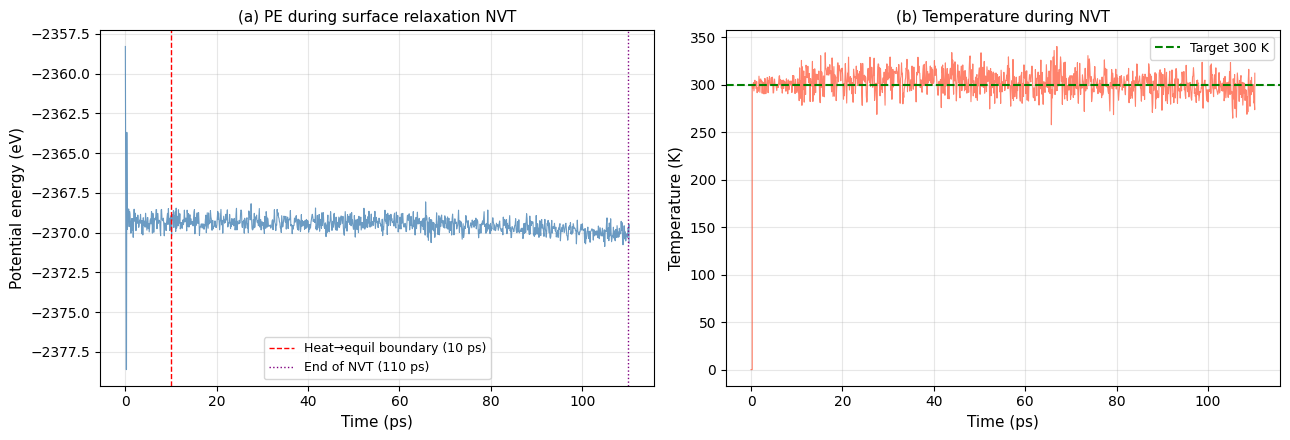

Saved: results/notebook04-surface-relaxation/12345/12345_relaxation.png


In [7]:
# ─────────────────────────────────────────────────────────────
# Plot (a): Potential energy vs time during NVT
# Plot (b): Temperature vs time during NVT
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) PE vs time
ax = axes[0]
if thermo.get('time') and thermo.get('pe'):
    ax.plot(thermo['time'], thermo['pe'], 'steelblue', lw=0.8, alpha=0.8)
    ax.set_xlabel('Time (ps)', fontsize=11)
    ax.set_ylabel('Potential energy (eV)', fontsize=11)
    ax.set_title('(a) PE during surface relaxation NVT', fontsize=11)
    ax.grid(True, alpha=0.3)
    t_heat  = HEAT_STEPS * TIMESTEP          # ps  e.g. 20000 * 0.0005 = 10 ps
    t_total = (HEAT_STEPS + NVT_STEPS) * TIMESTEP  # ps  e.g. 220000 * 0.0005 = 110 ps

    ax.axvline(t_heat,  color='red',    ls='--', lw=1,
            label=f'Heat→equil boundary ({t_heat:.0f} ps)')
    ax.axvline(t_total, color='purple', ls=':',  lw=1,
            label=f'End of NVT ({t_total:.0f} ps)')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'Run SLURM job first', ha='center', va='center',
            transform=ax.transAxes, color='gray', fontsize=11)

# (b) Temperature vs time
ax = axes[1]
if thermo.get('time') and thermo.get('temp'):
    ax.plot(thermo['time'], thermo['temp'], 'tomato', lw=0.8, alpha=0.8)
    ax.axhline(TARGET_T, color='green', ls='--', lw=1.5, label=f'Target {TARGET_T} K')
    ax.set_xlabel('Time (ps)', fontsize=11)
    ax.set_ylabel('Temperature (K)', fontsize=11)
    ax.set_title('(b) Temperature during NVT', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Run SLURM job first', ha='center', va='center',
            transform=ax.transAxes, color='gray', fontsize=11)

plt.tight_layout()
plt.savefig('results/notebook04-surface-relaxation/12345/12345_relaxation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/notebook04-surface-relaxation/12345/12345_relaxation.png')

### 3.8 — Decision Cell

In [8]:
print(meta)

{'frozen_count': 120, 'free_count': 240, 'z_top_before_Ang': 38.6535291086207, 'z_top_after_min_Ang': 38.6535291086207, 'surface_contraction': 0.0, 'z_top_after_nvt_Ang': 38.6535291086207, 'pe_final_eV': -2370.67654974438}


In [9]:
# ─────────────────────────────────────────────────────────────
# All checks must pass before Notebook 05
# ─────────────────────────────────────────────────────────────

print('=' * 62)
print('  NOTEBOOK 04 — FINAL DECISION')
print('=' * 62)

relaxed_exists = os.path.exists(SLAB_RELAXED)
log_exists     = os.path.exists(RELAX_LOG)

# Check surface contraction is physically reasonable
contraction_ok = False
contraction_val = meta.get('surface_contraction', None)
if contraction_val is not None:
    # Expect small inward contraction: 0 to -0.2 Å is normal [8,9]
    # Positive = expanded (unusual but possible for alloys)
    contraction_ok = abs(contraction_val) < 0.5

# Check temperature reached target
temp_ok = False
if thermo.get('temp') and len(thermo['temp']) > 10:
    # Average temperature in last 50% of NVT run
    half = len(thermo['temp']) // 2
    avg_temp = np.mean(thermo['temp'][half:])
    temp_ok = abs(avg_temp - TARGET_T) < 50  # within 50 K
    print(f'  Average T (last 50% NVT): {avg_temp:.1f} K  (target: {TARGET_T} K)')

checks = [
    ('Input slab exists (Notebook 03)',           os.path.exists(SLAB_INPUT)),
    ('Relaxation log exists',                     log_exists),
    ('Relaxed slab file written',                 relaxed_exists),
    (f'Surface contraction physically reasonable', contraction_ok),
    (f'Temperature reached ~{TARGET_T} K',         temp_ok),
]

all_pass = True
for label, ok in checks:
    print(f'  {"✓" if ok else "✗"} {label}')
    if not ok:
        all_pass = False

print()
if all_pass:
    print('  ✅ ALL CHECKS PASSED')
    print(f'  → Proceed to Notebook 05 (H₂ Adsorption Energy)')
    print(f'  → Use: {SLAB_RELAXED}')
    print(f'  → This is the CLEAN SURFACE REFERENCE for all NB05-09')
else:
    print('  ❌ CHECKS FAILED — do NOT proceed to Notebook 05')
    print('  Resolve all ✗ items above.')
print('=' * 62)

  NOTEBOOK 04 — FINAL DECISION
  Average T (last 50% NVT): 299.7 K  (target: 300 K)
  ✓ Input slab exists (Notebook 03)
  ✓ Relaxation log exists
  ✓ Relaxed slab file written
  ✓ Surface contraction physically reasonable
  ✓ Temperature reached ~300 K

  ✅ ALL CHECKS PASSED
  → Proceed to Notebook 05 (H₂ Adsorption Energy)
  → Use: structures/notebook04-surface-relaxation/12345/hastelloy_12345_slab_relaxed.lammps
  → This is the CLEAN SURFACE REFERENCE for all NB05-09
